# <div align="center"><u>Project 11 - Version 2</u>
    
- The following analysis focuses on the binary classification of healthy individuals versus cancer patients. The specific pathology addressed is Pancreatic Ductal Adenocarcinoma (PDAC), which accounts for approximately 90% of all pancreatic cancer cases. Due to the asymptomatic nature of its early stages, early detection remains a significant hurdle. Consequently, it is a high-priority challenge for researchers to develop machine learning algorithms and diagnostic solutions capable of identifying the disease in its infancy.
    
- The dataset utilized in this study consists of synthetic data, generated to reflect real-world clinical distributions. Each record adheres to established medical parameters and biological constraints observed in Pancreatic Ductal Adenocarcinoma (PDAC) patients and healthy controls. Additionally, several non-oncological parameters were included to introduce noise into the dataset. This allows for a more rigorous evaluation of the machine learning algorithms' effectiveness and their ability to maintain predictive accuracy in the presence of irrelevant features:
    
    - Well-established bioindicators:
        - CA19-9, 12.5 (±8.0) for healthy, 450 (±210) for cancer, primary pancreatic rumor marker.
        - CEA, 1.8 (±1.2) for healthy, 8.5 (±5.5) for cancer, general marker for GI tract cancer.
        - Bilirubin(Total), 0.6 (±0.3) for healthy, 2.4 (±1.8) for cancer, elevated if tumor blocks bile ducts.
        - Alkaline Phosphatase, 70.0 (±20.0) for healthy, 210.0 (±95.0) for cancer, indicates liver/bile duct stress.
        - ALT (Alanine Aminotransferase), 25.0 (±10.0) for healthy, 55.0 (±30.0) for cancer, marker for secondary liver impact.
        - Albumin, 4.4 (±0.4) for healthy, 3.2 (±0.7) for cancer, drops due to inflammation/malnutrition.
        - CRP (C-Reactive Protein), 1.5 (±1.0) for healthy, 15.0 (±12.0) for cancer, general systemic inflammation marker.
        - Glucose (Fasting), 90.0 (±10.0) for healthy, 135.0 (±40.0) for cancer, New-onset diabetes is a PDAC sympton.
        - Hemoglobin, 14.5 (±1.5) for healthy, 11.5 (±2.0) for cancer, cancer often causes mild anemia.
        - Platelet Count, 250 (±60) for healthy, 380 (±110) for cancer, paraneoplastic thrombocytosis (high platelets).
    - Noise bioindicators:
        - Vitamin B12, 450.0 (±150.0) for healthy, 450 (±160) for cancer, Generally unaffected by early PDAC.
        - TSH (Thyroid), 2.1 (±1.1) for healthy, 2.2 (±1.2) for cancer, standard thyroid function marker.
        - Calcium, 9.5 (±0.5) for healthy, 9.4 (±0.6) for cancer, bone/parathyroid marker.
        - Chloride, 102.0 (±3.0) for healthy, 101.5 (±3.5) for cancer, basic electrolyte balance.
        - Potassium, 4.1 (±0.4) for healthy, 4.0 (±0.5) for cancer, marker essential mineral/electrolyte.
        - Creatinine, 0.9 (±0.2) for healthy, 1.0 (±0.3) for cancer, primary marker for kidney function.
        - HDL Cholesterol, 55.0 (±12.0) for healthy, 53.0 (±14.0) for cancer, "good" cholesterol;lipid profile.
        - HBA1c, 5.3 (±0.4) for healthy, 5.5 (±0.6) for cancer, 3-month average blood sugar.
        - Vitamin D, 32.0 (±10.0) for healthy, 30.0 (±12.0) for cancer, bone and immune health.
        - Uric acid, 5.0 (±1.2) for healthy, 5.2 (±1.4) for cancer, metabolic byproduct;gout marker.
        
       

##############################################################################################################################

###  Import libraries

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random
import time

import random
import time

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

### Suppress warnings

In [86]:
# Suppress all warnings
import warnings

warnings.filterwarnings("ignore")

### Start time

In [87]:
# Start time
start_time = time.time()

### Create some data

In [88]:
# Set seed for reproducibility
np.random.seed(42)

# Function that generates data based on real life spectrum values
def generate_data(n_samples, label):
    data = {
        # --- Cancer-Related Indicators (High Signal) ---
        'CA_19_9':       np.random.normal(12.5 if label == 0 else 450.0, 8.0 if label == 0 else 210.0, n_samples),
        'CEA':           np.random.normal(1.8  if label == 0 else 8.5,   1.2 if label == 0 else 5.5,   n_samples),
        'Bilirubin':     np.random.normal(0.6  if label == 0 else 2.4,   0.3 if label == 0 else 1.8,   n_samples),
        'Alkaline_Phos': np.random.normal(70.0 if label == 0 else 210.0, 20.0 if label == 0 else 95.0, n_samples),
        'ALT':           np.random.normal(25.0 if label == 0 else 55.0,  10.0 if label == 0 else 30.0, n_samples),
        'Albumin':       np.random.normal(4.4  if label == 0 else 3.2,   0.4 if label == 0 else 0.7,   n_samples),
        'CRP':           np.random.normal(1.5  if label == 0 else 15.0,  1.0 if label == 0 else 12.0,  n_samples),
        'Glucose':       np.random.normal(90.0 if label == 0 else 135.0, 10.0 if label == 0 else 40.0, n_samples),
        'Hemoglobin':    np.random.normal(14.5 if label == 0 else 11.5,  1.5 if label == 0 else 2.0,   n_samples),
        'Platelets':     np.random.normal(250  if label == 0 else 380,   60  if label == 0 else 110,   n_samples),
        
        # --- Non-Related Indicators (Low Signal/Noise) ---
        'Vitamin_B12': np.random.normal(450.0 if label == 0 else 445.0, 150.0 if label == 0 else 160.0, n_samples),
        'TSH':         np.random.normal(2.1   if label == 0 else 2.2,   1.1   if label == 0 else 1.2,   n_samples),
        'Calcium':     np.random.normal(9.5   if label == 0 else 9.4,   0.5   if label == 0 else 0.6,   n_samples),
        'Chloride':    np.random.normal(102.0 if label == 0 else 101.5, 3.0   if label == 0 else 3.5,   n_samples),
        'Potassium':   np.random.normal(4.1   if label == 0 else 4.0,   0.4   if label == 0 else 0.5,   n_samples),
        'Creatinine':  np.random.normal(0.9   if label == 0 else 1.0,   0.2   if label == 0 else 0.3,   n_samples),
        'HDL_Chol':    np.random.normal(55.0  if label == 0 else 53.0,  12.0  if label == 0 else 14.0,  n_samples),
        'HBA1c':       np.random.normal(5.3   if label == 0 else 5.5,   0.4   if label == 0 else 0.6,   n_samples),
        'Vitamin_D':   np.random.normal(32.0  if label == 0 else 30.0,  10.0  if label == 0 else 12.0,  n_samples),
        'Uric_Acid':   np.random.normal(5.0   if label == 0 else 5.2,   1.2   if label == 0 else 1.4,   n_samples),
        
        'Target': [label] * n_samples
    }
    return pd.DataFrame(data) # Added return statement

# Set number of samples for each
n_samples = 100

# Generate 100 samples for each
healthy_df = generate_data(n_samples, 0) # 0 = Healthy
cancer_df = generate_data(n_samples, 1)  # 1 = Cancer (PDAC)

# Combine and shuffle
df = pd.concat([healthy_df, cancer_df]).sample(frac=1).reset_index(drop=True)

# Ensure no negative values (biological constraint)
df[df.columns[:-1]] = df[df.columns[:-1]].clip(lower=0.1)

df

,CA_19_9,CEA,Bilirubin,Alkaline_Phos,ALT,Albumin,CRP,Glucose,Hemoglobin,Platelets,...,TSH,Calcium,Chloride,Potassium,Creatinine,HDL_Chol,HBA1c,Vitamin_D,Uric_Acid,Target
0,15.393088,1.505534,0.467987,71.953522,19.694989,3.651683,0.100000,83.730329,15.487816,247.590523,...,2.754230,9.132235,100.670153,3.621647,0.587491,65.087440,5.349282,21.090336,4.766110,0
1,277.955849,5.110012,3.054537,234.818800,99.617385,3.574240,25.254303,116.933621,10.473607,572.209952,...,0.242469,9.488854,100.920290,5.026486,0.990316,58.097964,4.318646,28.184409,4.344061,1
2,283.591817,3.716853,3.695564,173.522729,38.599597,2.968084,7.375651,215.490818,12.199600,317.318378,...,4.179377,9.533374,102.258187,4.097741,1.013567,81.697369,4.950207,15.392608,7.536697,1
3,304.110242,9.406185,2.590610,276.388700,107.487517,2.703294,36.711676,151.594620,12.091249,489.622756,...,3.216125,9.407500,103.971276,4.072761,1.099255,46.042952,5.071192,22.628122,5.730814,1
4,2.733251,3.659921,0.790176,67.058852,25.740948,4.418959,0.100000,94.725975,14.851322,219.876747,...,3.160496,10.319558,100.988742,4.213032,0.581059,50.156218,4.653476,35.615035,3.196436,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,381.142110,7.932099,2.059583,275.880497,31.487030,3.914968,15.187420,150.452933,10.284249,359.441423,...,2.067202,9.537398,103.876260,3.806150,0.666526,63.960232,6.357315,28.200711,4.808009,1
196,189.755737,7.449347,1.955354,105.485348,15.205836,2.604015,32.469868,139.941908,7.644655,522.545896,...,4.186489,9.832888,109.620143,3.733916,0.334954,65.525061,5.436198,15.791633,5.116819,1
197,16.840480,1.710665,1.755819,65.956147,30.144388,4.067620,2.996044,106.964564,13.158089,379.795283,...,4.205434,10.374788,103.424095,3.999667,1.195506,51.971758,4.910188,40.950383,5.171532,0
198,15.092672,2.100591,0.221735,76.218151,24.373209,4.434636,3.348956,80.767668,13.565289,235.525837,...,1.009468,9.665440,98.489661,4.223533,0.879969,61.955598,4.218707,25.537727,2.872361,0


### Define parameters

In [89]:
# Define parameters
number_of_splits = 50       # Number of MCCV iterations
test_size = 0.25            # 25% test data
number_of_neighbors = 3      # Number of neighbors

### Prepare data

In [90]:
# Prepare data
X = df.iloc[:, :-1].values  # Features
y = df['Target'].values     # Classes-Labels

### Function that applies Monte Carlo Cross Validation (MCCV)

In [91]:
# Function that applies Monte Carlo Cross Validation
def kNN_MCCV(X, y, n_neighbors, test_size, num_splits): # Removed default values from def for clarity with external variables
    
    train_scores = np.zeros(num_splits)
    test_scores = np.zeros(num_splits)
    train_losses = np.zeros(num_splits)
    test_losses = np.zeros(num_splits)

    test_precision_scores = np.zeros(num_splits)
    test_recall_scores = np.zeros(num_splits)
    test_f1_scores = np.zeros(num_splits)
    test_auc_roc_scores = np.zeros(num_splits)

    labels = np.unique(y)
    n_classes = len(labels)
    cm_total = np.zeros((n_classes, n_classes), dtype=np.float64)

    for i in range(num_splits):
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, shuffle=True, stratify=y, random_state=i
        )

        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        model = KNeighborsClassifier(n_neighbors=n_neighbors)
        model.fit(x_train_scaled, y_train)

        y_train_pred = model.predict(x_train_scaled)
        y_test_pred = model.predict(x_test_scaled)

        # Calculate accuracy for train and test
        train_scores[i] = accuracy_score(y_train, y_train_pred)
        test_scores[i] = accuracy_score(y_test, y_test_pred)

        # Calculate and store precision, recall, f1_score and AUC-ROC metrics for the test set
        test_precision_scores[i] = precision_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        test_recall_scores[i] = recall_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        test_f1_scores[i] = f1_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        
        # If predict_proba is available
        if hasattr(model, "predict_proba"):
            y_train_proba = model.predict_proba(x_train_scaled)
            y_test_proba = model.predict_proba(x_test_scaled)

            test_auc_roc_scores[i] = roc_auc_score(y_test, y_test_proba[:, 1])
                
        else:
            test_auc_roc_scores[i] = np.nan

        cm = confusion_matrix(y_test, y_test_pred, labels=labels)
        cm_total += cm

    cm_avg = cm_total / num_splits
    
    return (
        train_scores,
        test_scores,
        test_precision_scores, 
        test_recall_scores,     
        test_f1_scores,         
        test_auc_roc_scores,    
        cm_avg,
        labels,
    )

### Apply MCCV

In [92]:
# Apply MCCV for kNN
train_scores, test_scores, \
test_precision_scores, test_recall_scores, test_f1_scores, test_auc_roc_scores, \
cm_avg, labels = kNN_MCCV(
    X, y, n_neighbors=number_of_neighbors, test_size=test_size, num_splits=number_of_splits
)

### Print results

In [93]:
print(f"Avg Training Accuracy: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
print(f"Avg Evaluation Accuracy:  {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")
print("")
print(f"Avg Evaluation Precision: {np.mean(test_precision_scores):.4f} ± {np.std(test_precision_scores):.4f}")
print(f"Avg Evaluation Recall:    {np.mean(test_recall_scores):.4f} ± {np.std(test_recall_scores):.4f}")
print(f"Avg Evaluation F1-Score:  {np.mean(test_f1_scores):.4f} ± {np.std(test_f1_scores):.4f}")
print(f"Avg Evaluation AUC-ROC:   {np.mean(test_auc_roc_scores):.4f} ± {np.std(test_auc_roc_scores):.4f}")

Avg Training Accuracy: 0.9625 ± 0.0094
Avg Evaluation Accuracy:  0.9540 ± 0.0266

Avg Evaluation Precision: 1.0000 ± 0.0000
Avg Evaluation Recall:    0.9080 ± 0.0532
Avg Evaluation F1-Score:  0.9510 ± 0.0296
Avg Evaluation AUC-ROC:   0.9880 ± 0.0155


### Accuracy over MCCV iterations

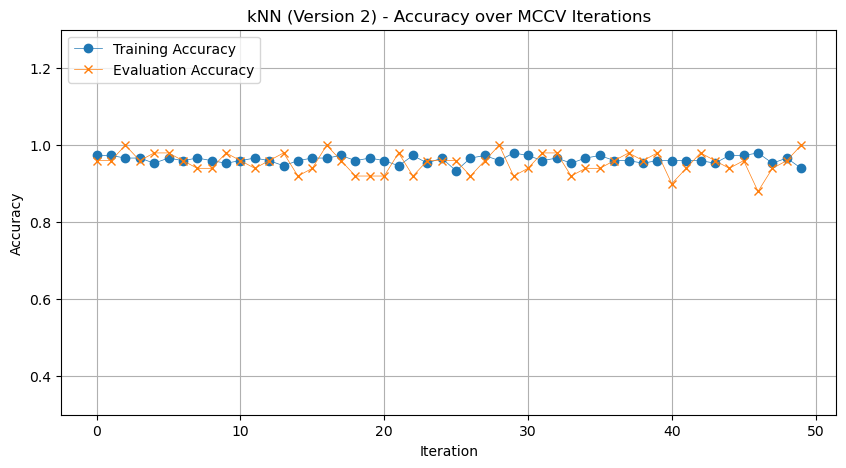

In [94]:
# Accuracy over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Training Accuracy', marker='o', linewidth=0.5)
plt.plot(test_scores, label='Evaluation Accuracy', marker='x', linewidth=0.5)
plt.title("kNN (Version 2) - Accuracy over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(0.3, 1.3)
plt.show()

### Plot the average confussion matrix

In [95]:
# Function that plots the average confussion matrix
def plot_confusion_matrix(cm, labels, title='kNN (Version 2) MCCV - Average Confusion Matrix', cmap='Blues'):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=labels,
                yticklabels=labels)

    plt.title(title, fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

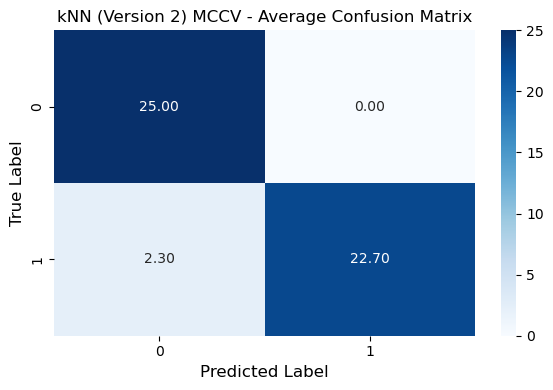

In [96]:
# Plot confusion matrix
plot_confusion_matrix(cm_avg, labels)

### End time

In [97]:
# End time
end_time = time.time()

### Elapsed time

In [98]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for kNN (Version 2): {elapsed_time:.2f} seconds")

Elapsed time for kNN (Version 2): 22.59 seconds
